In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [5]:
# Directories
PROJECT_DIR = r"C:/Users/skazempour/Dropbox/Projects/42 - Machine learning from the crowd/"

CODE_DIR = os.path.join(PROJECT_DIR, "Code")
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
FIGURES_DIR = os.path.join(PROJECT_DIR, "Figures")
TABLES_DIR = os.path.join(PROJECT_DIR, "Tables")

# File names
INPUT_DATA = os.path.join(DATA_DIR, "merged_master.pkl")

# Sample period
SAMPLE_START = '2012-01-01'
SAMPLE_END = '2022-12-31'

# Model registry
MODELS = {
    'lr_2': 'predictions_linear_regression_input=2.pkl',
    'lr_56': 'predictions_linear_regression_input=56.pkl',
}

# Prediction target
TARGET = 'f_cumret1'

# Load and merge data

In [6]:
# Load base data
df = pd.read_pickle(INPUT_DATA)[['date', 'permno', 'ticker', TARGET, 'log_volume']].copy()

# Merge predictions from each model
for model_name, pred_file in MODELS.items():
    preds = pd.read_pickle(os.path.join(DATA_DIR, pred_file))
    df[model_name] = preds.set_index('index')['prediction']

# Keep only rows with at least one prediction (OOS period)
model_cols = list(MODELS.keys())
df = df.dropna(subset=model_cols, how='all').reset_index(drop=True)

# Restrict to sample period
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= SAMPLE_START) & (df['date'] <= SAMPLE_END)].reset_index(drop=True)
df['year_month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year

print(f"OOS sample: {len(df):,} rows")
print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Models loaded: {model_cols}")
for col in model_cols:
    print(f"  {col}: {df[col].notna().sum():,} predictions")

OOS sample: 12,047,638 rows
Period: 2012-01-03 to 2022-12-30
Models loaded: ['lr_2', 'lr_56']
  lr_2: 12,047,638 predictions
  lr_56: 12,047,638 predictions


# Daily cross-sectional rank correlations

In [7]:
def daily_rank_corr(group, model_cols, target):
    """Compute Spearman rank correlation between each model's predictions and realized returns for one day."""
    result = {}
    for col in model_cols:
        valid = group[[target, col]].dropna()
        if len(valid) < 10:
            result[col] = np.nan
        else:
            corr, _ = spearmanr(valid[col], valid[target])
            result[col] = corr
    result['N'] = len(group)
    return pd.Series(result)

In [8]:
daily_corr = df.groupby('date').apply(daily_rank_corr, model_cols=model_cols, target=TARGET)
daily_corr['year'] = daily_corr.index.year
daily_corr['year_month'] = daily_corr.index.to_period('M')

print(f"Daily rank correlations computed for {len(daily_corr):,} days")
print(f"\nSummary statistics:")
print(daily_corr[model_cols].describe())

Daily rank correlations computed for 2,768 days

Summary statistics:
              lr_2        lr_56
count  2768.000000  2768.000000
mean      0.010822     0.003811
std       0.067592     0.051551
min      -0.316507    -0.264460
25%      -0.021205    -0.021227
50%       0.009020     0.003739
75%       0.042605     0.028360
max       0.328024     0.251250


C:\Users\skazempour\AppData\Local\Temp\ipykernel_21576\1245531121.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_corr = df.groupby('date').apply(daily_rank_corr, model_cols=model_cols, target=TARGET)


# Full sample rank correlation

In [9]:
# Full sample: average of daily cross-sectional rank correlations
full_sample = daily_corr[model_cols].mean()

print("Full Sample Average Daily Rank Correlation (Spearman)")
print("=" * 50)
for col in model_cols:
    print(f"  {col}: {full_sample[col]:.6f}")

Full Sample Average Daily Rank Correlation (Spearman)
  lr_2: 0.010822
  lr_56: 0.003811


# Yearly rank correlation

In [10]:
# Yearly: average of daily cross-sectional rank correlations within each year
yearly_corr = daily_corr.groupby('year')[model_cols].mean()

print("Yearly Average Daily Rank Correlation (Spearman)")
print("=" * 50)
print(yearly_corr.to_string(float_format='{:.6f}'.format))

Yearly Average Daily Rank Correlation (Spearman)
          lr_2     lr_56
year                    
2012  0.001284 -0.000265
2013  0.002133  0.001224
2014  0.009868  0.001005
2015  0.011221  0.001378
2016  0.013474  0.004610
2017  0.015472  0.004948
2018  0.012167  0.001739
2019  0.013057  0.008551
2020 -0.004668  0.001751
2021  0.010852 -0.001736
2022  0.034284  0.018744


# Monthly rank correlation

In [11]:
# Monthly: average of daily cross-sectional rank correlations within each month
monthly_corr = daily_corr.groupby('year_month')[model_cols].mean()

print("Monthly Average Daily Rank Correlation (Spearman)")
print("=" * 50)
print(monthly_corr.to_string(float_format='{:.6f}'.format))

Monthly Average Daily Rank Correlation (Spearman)
                lr_2     lr_56
year_month                    
2012-01    -0.004236  0.005318
2012-02    -0.003471  0.001741
2012-03     0.000875  0.005994
2012-04     0.001997 -0.002435
2012-05     0.002172 -0.026235
2012-06     0.001348 -0.000248
2012-07     0.000790  0.003624
2012-08    -0.002215  0.005313
2012-09     0.008806  0.010067
2012-10     0.006194 -0.003249
2012-11     0.004566 -0.001720
2012-12    -0.000957  0.000322
2013-01     0.003913  0.003455
2013-02     0.007208 -0.001234
2013-03     0.004746  0.004675
2013-04    -0.010811  0.003112
2013-05    -0.004208  0.003395
2013-06     0.010252 -0.000314
2013-07    -0.004440 -0.001132
2013-08     0.004357  0.003228
2013-09     0.000263  0.009339
2013-10     0.004247 -0.002835
2013-11     0.006554  0.000991
2013-12     0.005550 -0.007546
2014-01     0.016123  0.004375
2014-02    -0.009732  0.005526
2014-03     0.031118  0.008309
2014-04     0.016383 -0.007562
2014-05     0.004498

# Plots

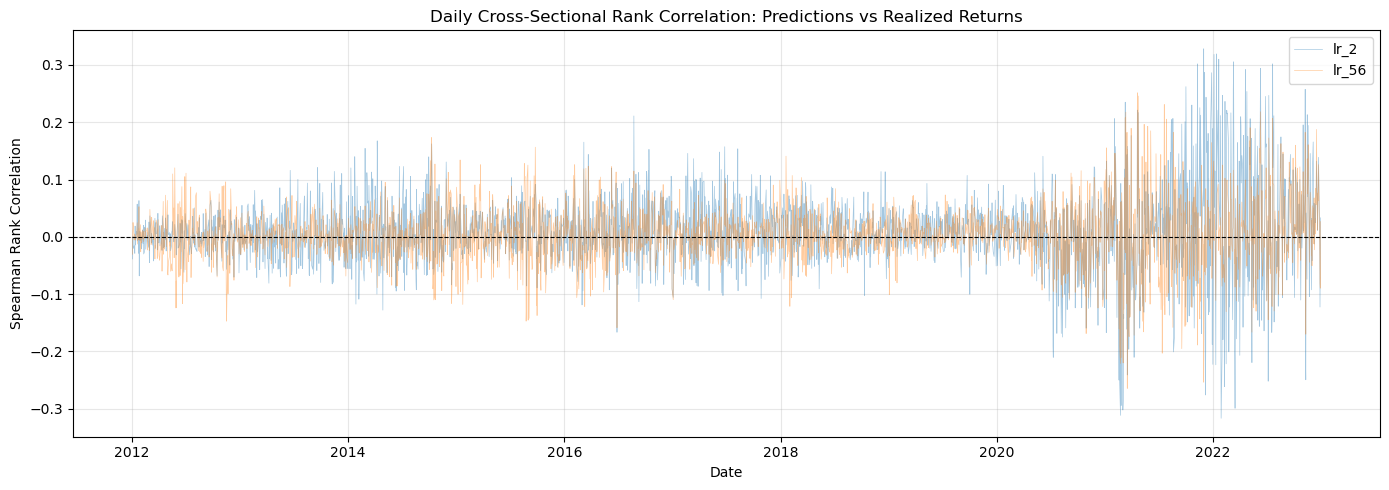

In [12]:
# Daily rank correlation time series
fig, ax = plt.subplots(figsize=(14, 5))
for col in model_cols:
    ax.plot(daily_corr.index, daily_corr[col], label=col, alpha=0.4, linewidth=0.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Spearman Rank Correlation')
ax.set_title('Daily Cross-Sectional Rank Correlation: Predictions vs Realized Returns')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

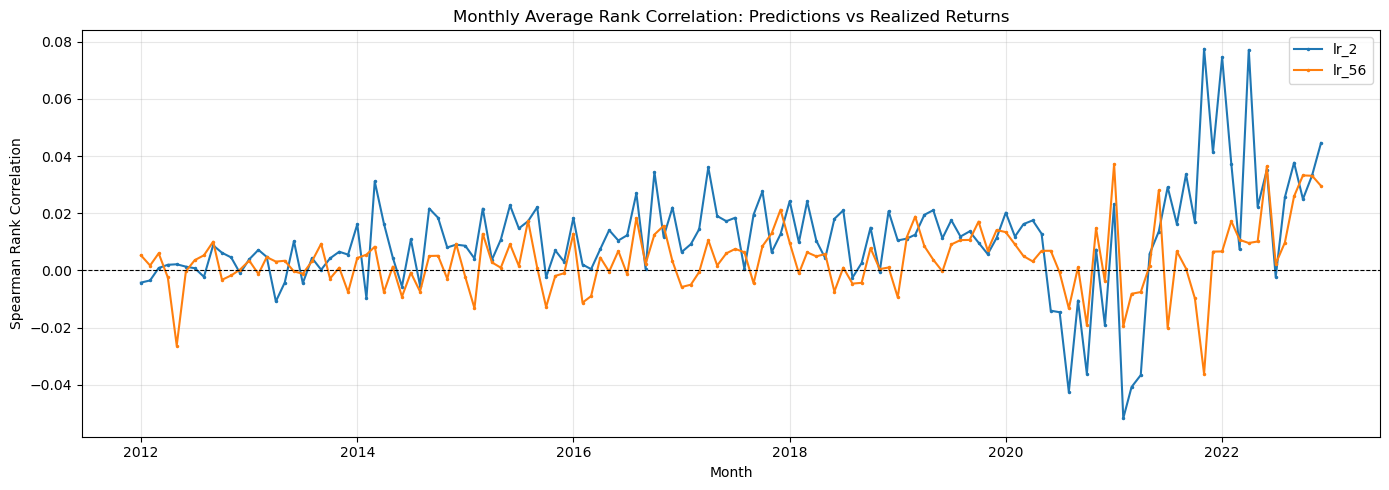

In [13]:
# Monthly average rank correlation
fig, ax = plt.subplots(figsize=(14, 5))
x = monthly_corr.index.to_timestamp()
for col in model_cols:
    ax.plot(x, monthly_corr[col], label=col, marker='.', markersize=3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Spearman Rank Correlation')
ax.set_title('Monthly Average Rank Correlation: Predictions vs Realized Returns')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

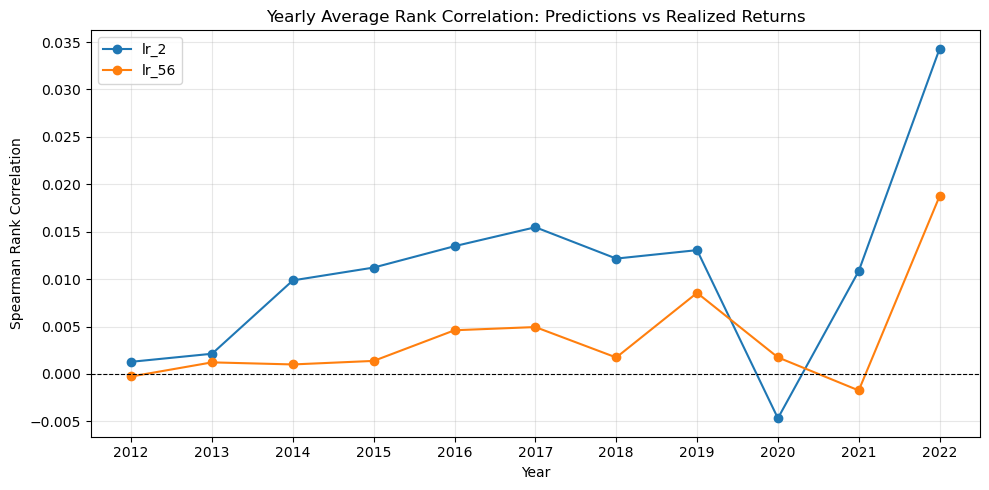

In [14]:
# Yearly average rank correlation
fig, ax = plt.subplots(figsize=(10, 5))
x = yearly_corr.index.astype(int)
for col in model_cols:
    ax.plot(x, yearly_corr[col], marker='o', label=col)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Spearman Rank Correlation')
ax.set_title('Yearly Average Rank Correlation: Predictions vs Realized Returns')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

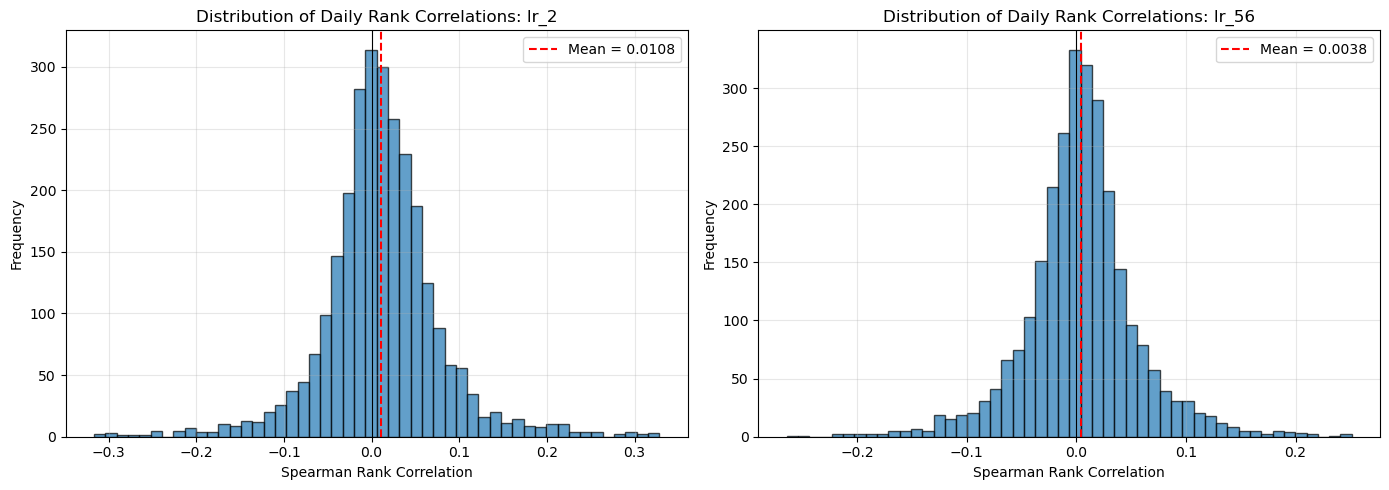

In [15]:
# Distribution of daily rank correlations
fig, axes = plt.subplots(1, len(model_cols), figsize=(7 * len(model_cols), 5))
if len(model_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, model_cols):
    vals = daily_corr[col].dropna()
    ax.hist(vals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=vals.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {vals.mean():.4f}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Spearman Rank Correlation')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Daily Rank Correlations: {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()